In [1]:
# Ejecuta esto primero. Solo se necesita una vez por sesión.
!pip install pandas openpyxl nltk scikit-learn networkx matplotlib seaborn wordcloud
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [7]:
import pandas as pd
import re

# ── Intentar leer como Excel real con openpyxl ─────────────────────────────
try:
    df_raw = pd.read_excel('/content/mensajes prueba.xlsx', engine='openpyxl')
    print("✅ Leído con openpyxl")
except Exception as e:
    print(f"openpyxl falló: {e}")
    # Segundo intento: xlrd
    try:
        df_raw = pd.read_excel('/content/mensajes prueba.xlsx', engine='xlrd')
        print("✅ Leído con xlrd")
    except Exception as e2:
        print(f"xlrd falló: {e2}")

# Ver estado real del archivo
print("\nColumnas:", df_raw.columns.tolist())
print("Shape:", df_raw.shape)
print("\nPrimera celda completa:")
print(repr(df_raw.iloc[0, 0]))  # Ver el contenido RAW de la primera celda

✅ Leído con openpyxl

Columnas: ['file,"message"']
Shape: (1853, 1)

Primera celda completa:
'allen-p/_sent_mail/1.,"Message-ID: <18782981.1075855378110.JavaMail.evans@thyme>'


In [8]:
import pandas as pd
import re

# ── Leer el Excel ──────────────────────────────────────────────────────────
df_raw = pd.read_excel('/content/mensajes prueba.xlsx', engine='openpyxl', header=0)

# La única columna se llama 'file,"message"' y contiene: ruta,contenido
col = df_raw.columns[0]

# ── Separar 'file' y 'message' dividiendo por la primera coma ─────────────
def split_row(row):
    text = str(row)
    # La ruta termina en el primer punto+coma o simplemente primera coma
    # Formato: allen-p/_sent_mail/1.,"Mensaje..."
    m = re.match(r'^([^,]+),(.*)$', text, re.DOTALL)
    if m:
        return pd.Series({'file': m.group(1).strip().strip('"'),
                          'message': m.group(2).strip().strip('"')})
    return pd.Series({'file': '', 'message': text})

df_split = df_raw[col].apply(split_row)

print("Shape tras separar:", df_split.shape)
print("\nEjemplo de 'file':", df_split['file'].iloc[0])
print("\nEjemplo de 'message' (primeros 200 chars):")
print(df_split['message'].iloc[0][:200])

Shape tras separar: (1853, 2)

Ejemplo de 'file': allen-p/_sent_mail/1.

Ejemplo de 'message' (primeros 200 chars):
Message-ID: <18782981.1075855378110.JavaMail.evans@thyme>


In [10]:
import pandas as pd
import re

# ── Releer y reparar saltos de línea escapados ─────────────────────────────
df_raw = pd.read_excel('/content/mensajes prueba.xlsx', engine='openpyxl', header=0)
col = df_raw.columns[0]

def split_row(row):
    text = str(row)
    m = re.match(r'^([^,]+),(.*)$', text, re.DOTALL)
    if m:
        file_part = m.group(1).strip().strip('"')
        msg_part  = m.group(2).strip().strip('"')
        # Convertir \n literales en saltos reales
        msg_part  = msg_part.replace('\\n', '\n').replace('\\r', '')
        return pd.Series({'file': file_part, 'message': msg_part})
    return pd.Series({'file': '', 'message': text})

df_split = df_raw[col].apply(split_row)

# ── Parseo corregido ───────────────────────────────────────────────────────
def parse_message(raw_text):
    raw = str(raw_text)

    def get_field(pattern):
        m = re.search(pattern, raw, re.IGNORECASE | re.MULTILINE)
        return m.group(1).strip() if m else ''

    from_addr = get_field(r'^From:\s*(.+)')
    to_addr   = get_field(r'^To:\s*(.+)')
    subject   = get_field(r'^Subject:\s*(.*)')
    date      = get_field(r'^Date:\s*(.+)')

    # Cuerpo: después del último encabezado X-FileName o primer línea vacía
    # Los correos Enron tienen encabezados X- al final del header
    parts = re.split(r'\n\s*\n', raw, maxsplit=1)
    body  = parts[1].strip() if len(parts) > 1 else ''

    return pd.Series({
        'from':    from_addr,
        'to':      to_addr,
        'subject': subject,
        'date':    date,
        'body':    body
    })

parsed   = df_split['message'].apply(parse_message)
df       = pd.concat([df_split['file'], parsed], axis=1)

# Filtrar: solo emails con @ y que no sean "Nombre@EMPRESA on fecha"
df = df[df['from'].str.match(r'^[\w.+-]+@[\w.-]+\.[a-z]{2,}$', na=False)]
df = df.reset_index(drop=True)

print(f"✅ Correos válidos: {len(df)}")
print(f"Remitentes únicos: {df['from'].nunique()}")
print(f"\nTop remitentes:")
print(df['from'].value_counts())

# Verificar que los campos se parsearon
print("\n── Ejemplo de correo 0 ──")
print(f"From:    {df.loc[0,'from']}")
print(f"To:      {df.loc[0,'to']}")
print(f"Subject: {df.loc[0,'subject']}")
print(f"Date:    {df.loc[0,'date']}")
print(f"Body:    {df.loc[0,'body'][:200]}")

✅ Correos válidos: 38
Remitentes únicos: 2

Top remitentes:
from
phillip.allen@enron.com    26
john.arnold@enron.com      12
Name: count, dtype: int64

── Ejemplo de correo 0 ──
From:    phillip.allen@enron.com
To:      
Subject: 
Date:    
Body:    


In [11]:
# Ver exactamente cómo está almacenado el texto en la celda
ejemplo = df_raw[col].iloc[0]
print("TIPO:", type(ejemplo))
print("\nREPR (primeros 500 chars):")
print(repr(str(ejemplo)[:500]))

TIPO: <class 'str'>

REPR (primeros 500 chars):
'allen-p/_sent_mail/1.,"Message-ID: <18782981.1075855378110.JavaMail.evans@thyme>'


In [12]:
import pandas as pd
import re

df_raw = pd.read_excel('/content/mensajes prueba.xlsx', engine='openpyxl', header=0)
col = df_raw.columns[0]

# Cada celda es una línea. Reconstruimos el texto completo
lineas = df_raw[col].astype(str).tolist()

# ── Agrupar líneas en mensajes ─────────────────────────────────────────────
# Cada mensaje nuevo empieza con una línea que contiene la ruta (allen-p/...)
# seguida de la primera línea del header (Message-ID o Date)
mensajes = []
mensaje_actual = []
file_actual = ''

for linea in lineas:
    # Detectar inicio de nuevo mensaje: línea con ruta tipo "allen-p/..."
    m_inicio = re.match(r'^([a-zA-Z_\-]+/[^\s,]+)\s*,?\s*(.*)', linea)
    if m_inicio and ('Message-ID' in linea or m_inicio.group(1).endswith('.')):
        # Guardar el mensaje anterior si existe
        if mensaje_actual:
            mensajes.append({'file': file_actual,
                             'message': '\n'.join(mensaje_actual)})
        file_actual   = m_inicio.group(1).strip().strip('"')
        primera_linea = m_inicio.group(2).strip().strip('"')
        mensaje_actual = [primera_linea] if primera_linea else []
    else:
        # Línea de continuación del mensaje actual
        mensaje_actual.append(linea.strip('"'))

# Guardar el último mensaje
if mensaje_actual:
    mensajes.append({'file': file_actual, 'message': '\n'.join(mensaje_actual)})

df_msgs = pd.DataFrame(mensajes)
print(f"Mensajes reconstruidos: {len(df_msgs)}")
print(f"\nEjemplo mensaje 0 (primeros 400 chars):")
print(df_msgs['message'].iloc[0][:400])

Mensajes reconstruidos: 17

Ejemplo mensaje 0 (primeros 400 chars):
Message-ID: <18782981.1075855378110.JavaMail.evans@thyme>
Date: Mon, 14 May 2001 16:39:00 -0700 (PDT)
From: phillip.allen@enron.com
To: tim.belden@enron.com
Subject: 
Mime-Version: 1.0
Content-Type: text/plain
Content-Transfer-Encoding: 7bit
X-From: Phillip K Allen
X-To: Tim Belden <Tim Belden/Enron@EnronXGate>
X-cc: 
X-bcc: 
X-Folder: \Phillip_Allen_Jan2002_1\Allen, Phillip K.\'Sent Mail
X-Origin


In [13]:
# ── Parsear campos de cada mensaje ────────────────────────────────────────
def parse_message(raw):
    raw = str(raw)

    def get_field(pattern):
        m = re.search(pattern, raw, re.IGNORECASE | re.MULTILINE)
        return m.group(1).strip() if m else ''

    from_addr = get_field(r'^From:\s*(.+)')
    to_addr   = get_field(r'^To:\s*(.+)')
    subject   = get_field(r'^Subject:\s*(.*)')
    date      = get_field(r'^Date:\s*(.+)')

    # Cuerpo: después de la línea X-FileName (último encabezado Enron)
    parts = re.split(r'X-FileName:.*?\n', raw, maxsplit=1, flags=re.IGNORECASE)
    body  = parts[1].strip() if len(parts) > 1 else ''

    # Si no encontró X-FileName, usar doble salto de línea
    if not body:
        parts = re.split(r'\n\s*\n', raw, maxsplit=1)
        body  = parts[1].strip() if len(parts) > 1 else ''

    return pd.Series({'from': from_addr, 'to': to_addr,
                      'subject': subject, 'date': date, 'body': body})

parsed = df_msgs['message'].apply(parse_message)
df     = pd.concat([df_msgs['file'], parsed], axis=1)
df     = df[df['from'].str.contains('@', na=False)].reset_index(drop=True)

print(f"\n✅ Correos válidos: {len(df)}")
print(f"Remitentes únicos: {df['from'].nunique()}")
print(f"\n── Ejemplo correo 1 ──")
print(f"From:    {df.loc[1,'from']}")
print(f"To:      {df.loc[1,'to']}")
print(f"Subject: {df.loc[1,'subject']}")
print(f"Body:    {df.loc[1,'body'][:200]}")


✅ Correos válidos: 17
Remitentes únicos: 2

── Ejemplo correo 1 ──
From:    phillip.allen@enron.com
To:      john.lavorato@enron.com
Subject: Re:
Body:    nan
Traveling to have a business meeting takes the fun out of the trip.  Especially if you have to prepare a presentation.  I would suggest holding the business plan meetings here then take a trip wit


In [14]:
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import numpy as np

STOP_EN = set(stopwords.words('english'))

# Conectores funcionales que queremos rastrear específicamente
CONNECTORS = {
    'adversativos': ['but', 'however', 'although', 'though', 'yet', 'nevertheless'],
    'causales':     ['because', 'since', 'therefore', 'thus', 'hence', 'so'],
    'aditivos':     ['and', 'also', 'furthermore', 'moreover', 'in addition'],
    'temporales':   ['then', 'when', 'while', 'after', 'before', 'once', 'finally'],
    'condicionales':['if', 'unless', 'provided', 'assuming'],
}
ALL_CONNECTORS = {w: cat for cat, words in CONNECTORS.items() for w in words}

def tokenize(text):
    """Tokeniza en minúsculas y filtra puntuación."""
    return re.findall(r'\b[a-z]{3,}\b', text.lower())

def analyze_sender(texts):
    """Recibe lista de textos de un remitente y devuelve métricas."""
    combined = ' '.join(texts)
    tokens   = tokenize(combined)

    # Palabras frecuentes (sin stopwords)
    content_words = [t for t in tokens if t not in STOP_EN]
    top_words     = Counter(content_words).most_common(15)

    # Conteo de conectores por categoría
    connector_counts = Counter()
    for t in tokens:
        if t in ALL_CONNECTORS:
            connector_counts[ALL_CONNECTORS[t]] += 1

    # Longitud promedio de correo
    avg_len = np.mean([len(tokenize(t)) for t in texts])

    return {
        'n_emails':          len(texts),
        'top_words':         top_words,
        'connector_counts':  dict(connector_counts),
        'avg_email_length':  round(avg_len, 1),
        'total_tokens':      len(tokens),
        'unique_tokens':     len(set(content_words)),
        'lexical_richness':  round(len(set(content_words)) / max(len(content_words), 1), 3)
    }

# Agrupar correos por remitente y calcular métricas
sender_groups = df.groupby('from')['body'].apply(list)
results = {sender: analyze_sender(texts) for sender, texts in sender_groups.items()}

# ── TF-IDF: temas dominantes por remitente ─────────────────────────────────
corpus    = [' '.join(texts) for texts in sender_groups]
senders   = list(sender_groups.index)

tfidf = TfidfVectorizer(stop_words='english', max_features=200, ngram_range=(1,2))
X     = tfidf.fit_transform(corpus)
terms = tfidf.get_feature_names_out()

for i, sender in enumerate(senders):
    top_idx  = X[i].toarray()[0].argsort()[-8:][::-1]
    top_terms = [terms[j] for j in top_idx]
    results[sender]['top_topics'] = top_terms

# ── Resumen en tabla ───────────────────────────────────────────────────────
summary = pd.DataFrame([{
    'remitente':        s,
    'correos':          r['n_emails'],
    'long_promedio':    r['avg_email_length'],
    'riqueza_léxica':   r['lexical_richness'],
    'top_5_palabras':   ', '.join([w for w, _ in r['top_words'][:5]]),
    'temas_TF-IDF':     ', '.join(r['top_topics'][:5]),
    'conector_dominante': max(r['connector_counts'], key=r['connector_counts'].get)
                          if r['connector_counts'] else '—'
} for s, r in results.items()])

summary.sort_values('correos', ascending=False, inplace=True)
print(summary.to_string(index=False))

              remitente  correos  long_promedio  riqueza_léxica                   top_5_palabras                       temas_TF-IDF conector_dominante
phillip.allen@enron.com       15          359.9           0.285  nan, enron, ect, allen, phillip  nan, enron, phillip, nan nan, ect           aditivos
  john.arnold@enron.com        2          823.0           0.285 nan, com, arnold, enron, carrfut nan, nan nan, com, arnold, carrfut           aditivos


In [15]:
display(summary)

,remitente,correos,long_promedio,riqueza_léxica,top_5_palabras,temas_TF-IDF,conector_dominante
1,phillip.allen@enron.com,15,359.9,0.285,"nan, enron, ect, allen, phillip","nan, enron, phillip, nan nan, ect",aditivos
0,john.arnold@enron.com,2,823.0,0.285,"nan, com, arnold, enron, carrfut","nan, nan nan, com, arnold, carrfut",aditivos


Nodos (personas): 18
Aristas (conexiones): 16

Top 10 remitentes por centralidad de grado:
  phillip.allen@enron.com                       0.882
  tim.belden@enron.com                          0.059
  john.lavorato@enron.com                       0.059
  randall.gay@enron.com                         0.059
  greg.piper@enron.com                          0.059
  david.l.johnson@enron.com                     0.059
  john.shafer@enron.com                         0.059
  mark.scott@enron.com                          0.059
  zimam@enron.com                               0.059
  stagecoachmama@hotmail.com                    0.059


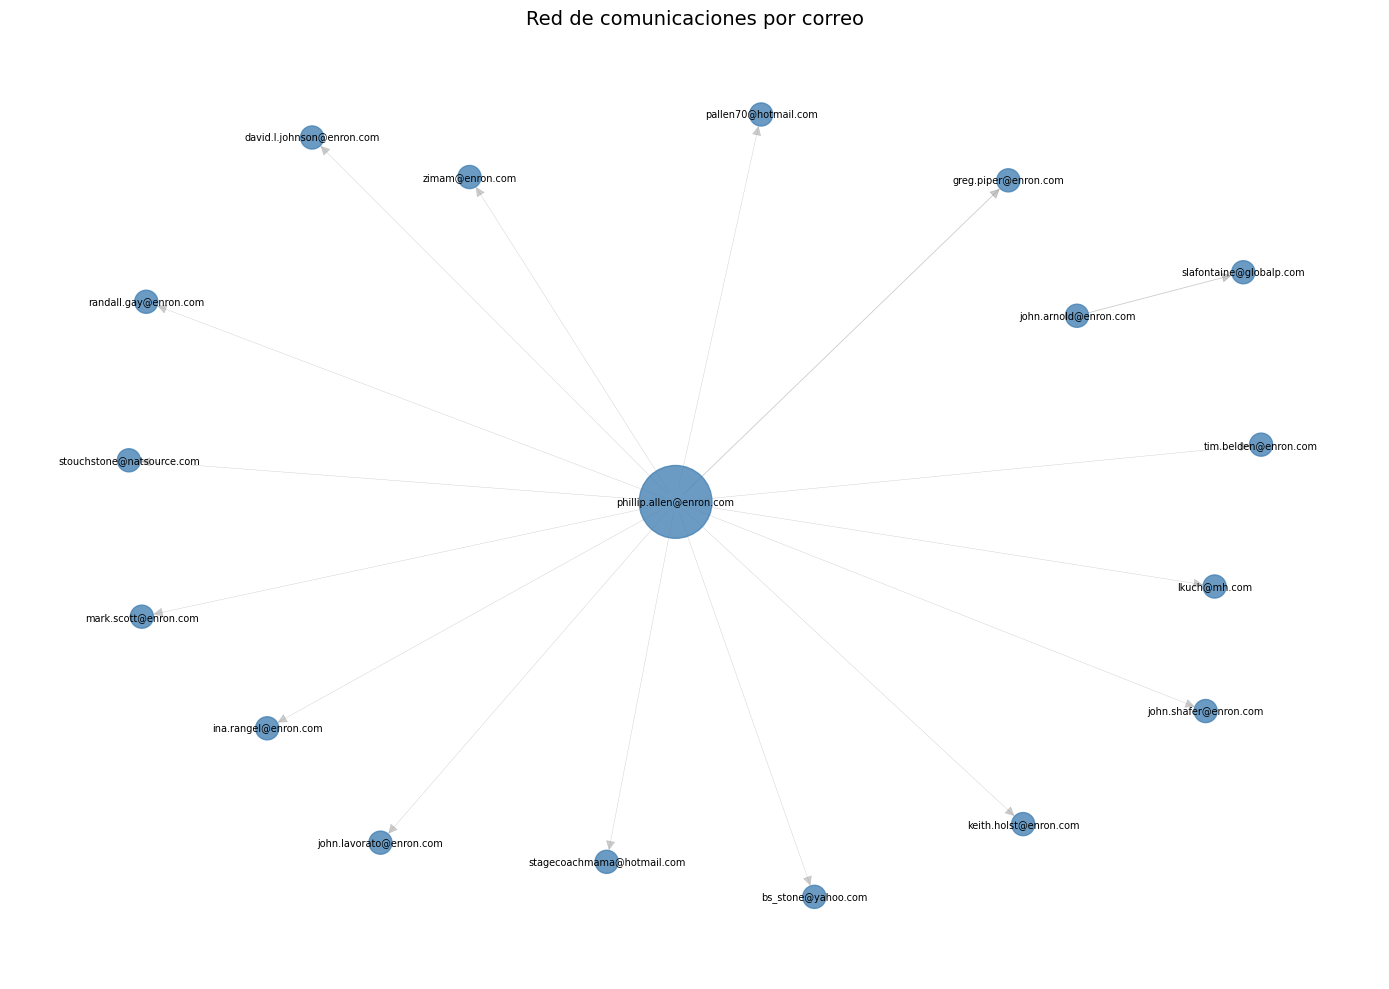

Guardada: red_comunicaciones.png


In [16]:
import networkx as nx
import matplotlib.pyplot as plt

# Construir grafo dirigido: From → To
G = nx.DiGraph()
for _, row in df.iterrows():
    frm = row['from']
    # 'to' puede tener múltiples destinatarios separados por coma
    for to in str(row['to']).split(','):
        to = to.strip()
        if frm and to and frm != to:
            if G.has_edge(frm, to):
                G[frm][to]['weight'] += 1
            else:
                G.add_edge(frm, to, weight=1)

print(f"Nodos (personas): {G.number_of_nodes()}")
print(f"Aristas (conexiones): {G.number_of_edges()}")

# Métricas de centralidad
degree_cent  = nx.degree_centrality(G)
betweenness  = nx.betweenness_centrality(G)
top_by_degree = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:10]

print("\nTop 10 remitentes por centralidad de grado:")
for node, val in top_by_degree:
    print(f"  {node:<45} {val:.3f}")

# Visualización
fig, ax = plt.subplots(figsize=(14, 10))
pos     = nx.spring_layout(G, k=0.5, seed=42)
sizes   = [3000 * degree_cent.get(n, 0.01) + 100 for n in G.nodes()]
weights = [G[u][v]['weight'] for u, v in G.edges()]

nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color='steelblue', alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, pos, width=[w * 0.3 for w in weights],
                       alpha=0.4, edge_color='gray',
                       arrows=True, arrowsize=15, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, ax=ax)

ax.set_title("Red de comunicaciones por correo", fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.savefig('red_comunicaciones.png', dpi=150)
plt.show()
print("Guardada: red_comunicaciones.png")

Perfil LIWC por remitente (% de palabras en cada categoría):

                         afecto_positivo  afecto_negativo  certeza  tentativo  pronombre_yo  pronombre_nos  tiempo_pasado  tiempo_futuro  negacion  interrogacion
remitente                                                                                                                                                        
phillip.allen@enron.com             0.31             0.17     0.11       0.28          0.02           0.20           0.41           1.41      0.41           0.43
john.arnold@enron.com               0.55             0.00     0.06       0.43          0.12           0.06           0.30           0.91      0.49           0.30


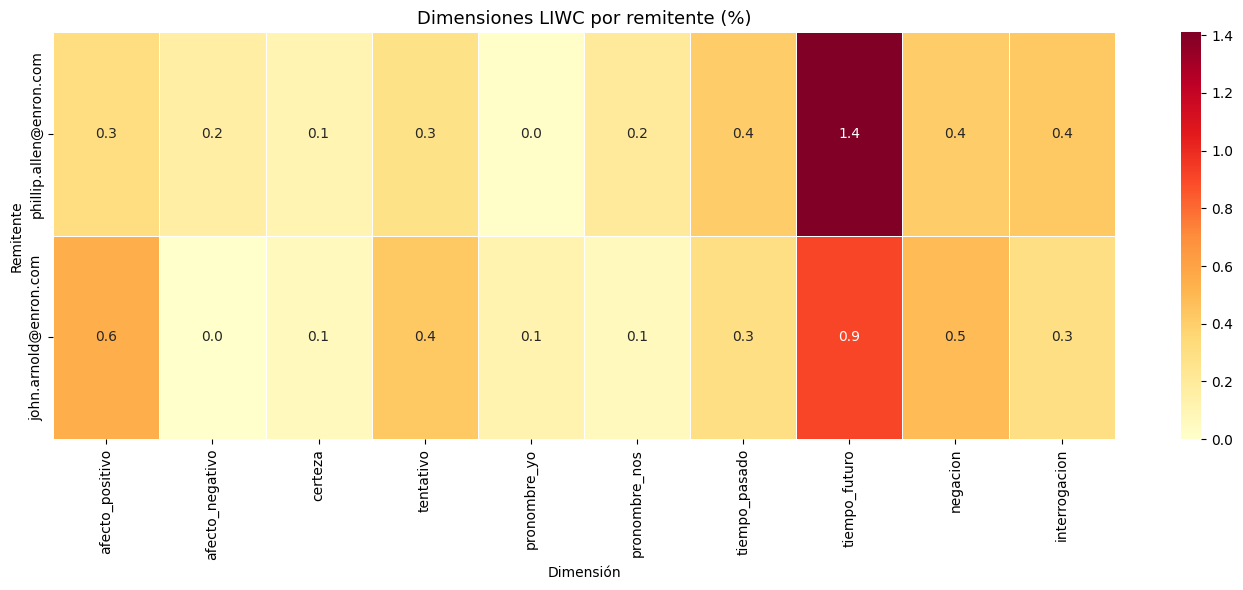

Guardada: liwc_heatmap.png


In [17]:
# Diccionarios de categorías LIWC simplificadas
LIWC_DICTS = {
    'afecto_positivo': ['good','great','happy','love','wonderful','excellent',
                        'fantastic','glad','pleased','enjoy','like','best'],
    'afecto_negativo': ['bad','hate','terrible','awful','sad','angry','fear',
                        'worry','problem','difficult','fail','wrong','sorry'],
    'certeza':         ['always','never','absolutely','certainly','definitely',
                        'must','clearly','obviously','undoubtedly'],
    'tentativo':       ['maybe','perhaps','might','could','possibly','seem',
                        'appear','think','guess','sometimes'],
    'pronombre_yo':    ['i','me','my','mine','myself'],
    'pronombre_nos':   ['we','us','our','ours','ourselves'],
    'tiempo_pasado':   ['was','were','had','did','went','said','told',
                        'found','came','took'],
    'tiempo_futuro':   ['will','shall','going','plan','expect','hope',
                        'would','should'],
    'negacion':        ['not','no','never','nothing','neither','nor','without'],
    'interrogacion':   ['who','what','where','when','why','how'],
}

def liwc_profile(text):
    """Calcula el % de tokens en cada categoría LIWC."""
    tokens = tokenize(text)
    n      = max(len(tokens), 1)
    return {cat: round(sum(1 for t in tokens if t in words) / n * 100, 2)
            for cat, words in LIWC_DICTS.items()}

# Calcular perfil LIWC medio por remitente
liwc_rows = []
for sender, texts in sender_groups.items():
    combined_profile = liwc_profile(' '.join(texts))
    combined_profile['remitente'] = sender
    combined_profile['correos']   = len(texts)
    liwc_rows.append(combined_profile)

df_liwc = pd.DataFrame(liwc_rows).set_index('remitente')
df_liwc = df_liwc.sort_values('correos', ascending=False)

print("Perfil LIWC por remitente (% de palabras en cada categoría):\n")
print(df_liwc.drop(columns='correos').round(2).to_string())

# Mapa de calor
import seaborn as sns

fig, ax = plt.subplots(figsize=(14, max(6, len(df_liwc) * 0.4)))
sns.heatmap(df_liwc.drop(columns='correos').astype(float),
            cmap='YlOrRd', annot=True, fmt='.1f',
            linewidths=0.5, ax=ax)
ax.set_title('Dimensiones LIWC por remitente (%)', fontsize=13)
ax.set_xlabel('Dimensión')
ax.set_ylabel('Remitente')
plt.tight_layout()
plt.savefig('liwc_heatmap.png', dpi=150)
plt.show()
print("Guardada: liwc_heatmap.png")